# Task 1: Exploring and Visualizing the Iris Dataset
**DevelopersHub Corporation – Data Science & Analytics Internship**

---

## Introduction & Problem Statement

The goal of this task is to develop foundational data science skills by loading, inspecting, and visualizing the classic **Iris dataset**. This dataset contains measurements (sepal length, sepal width, petal length, petal width) for 150 iris flowers across 3 species: *Setosa*, *Versicolor*, and *Virginica*.

**Objectives:**
- Load and inspect the dataset using `pandas`
- Summarize its structure and statistics
- Create scatter plots, histograms, and box plots using `matplotlib` and `seaborn`
- Draw meaningful insights from visualizations


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set a consistent visual style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Dataset Loading & Description

In [3]:
# Load Iris dataset via seaborn (no CSV needed, built-in)
df = sns.load_dataset('iris')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names: {list(df.columns)}")


Dataset loaded successfully!
Shape: 150 rows × 5 columns

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


## 2. Dataset Inspection

In [4]:
# Display first 5 rows
print("First 5 rows:")
df.head()


First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# Dataset shape and data types
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")


Shape: (150, 5)

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [6]:
# Statistical summary
print("Statistical Summary:")
df.describe()


Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# Class distribution
print("Species distribution:")
print(df['species'].value_counts())


Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

### 3.1 Scatter Plot – Relationship Between Variables

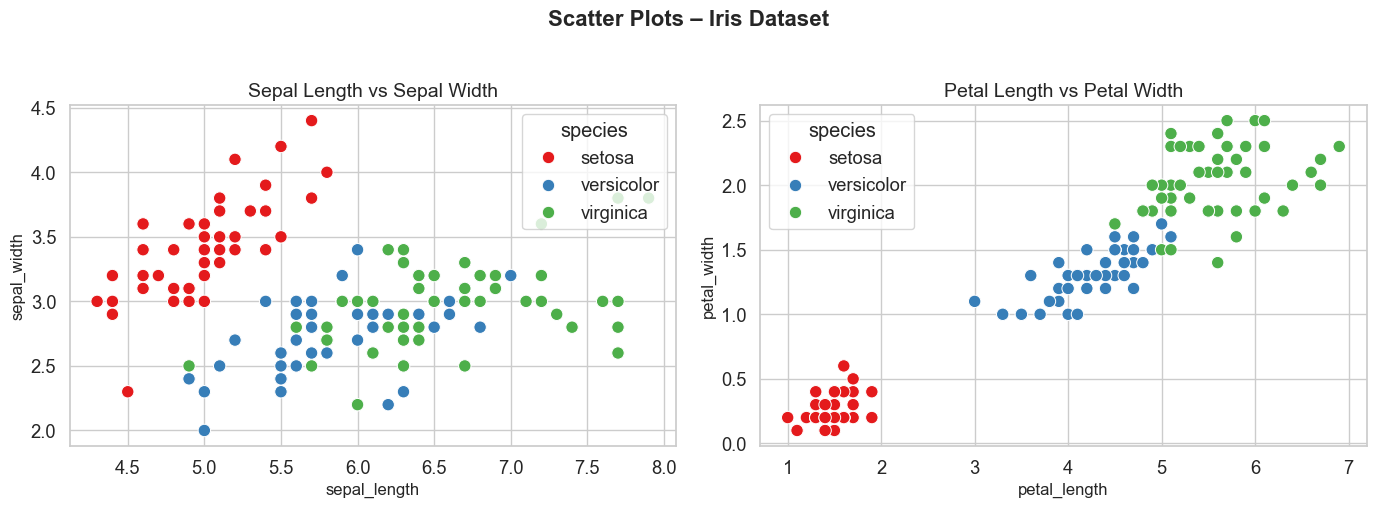


Insight: Petal dimensions show clear separation between species.


In [8]:
# Scatter plot: Sepal Length vs Sepal Width coloured by species
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='sepal_length', y='sepal_width',
                hue='species', palette='Set1', s=80, ax=axes[0])
axes[0].set_title('Sepal Length vs Sepal Width')

sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set1', s=80, ax=axes[1])
axes[1].set_title('Petal Length vs Petal Width')

plt.suptitle('Scatter Plots – Iris Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Petal dimensions show clear separation between species.")


### 3.2 Histogram – Feature Distributions

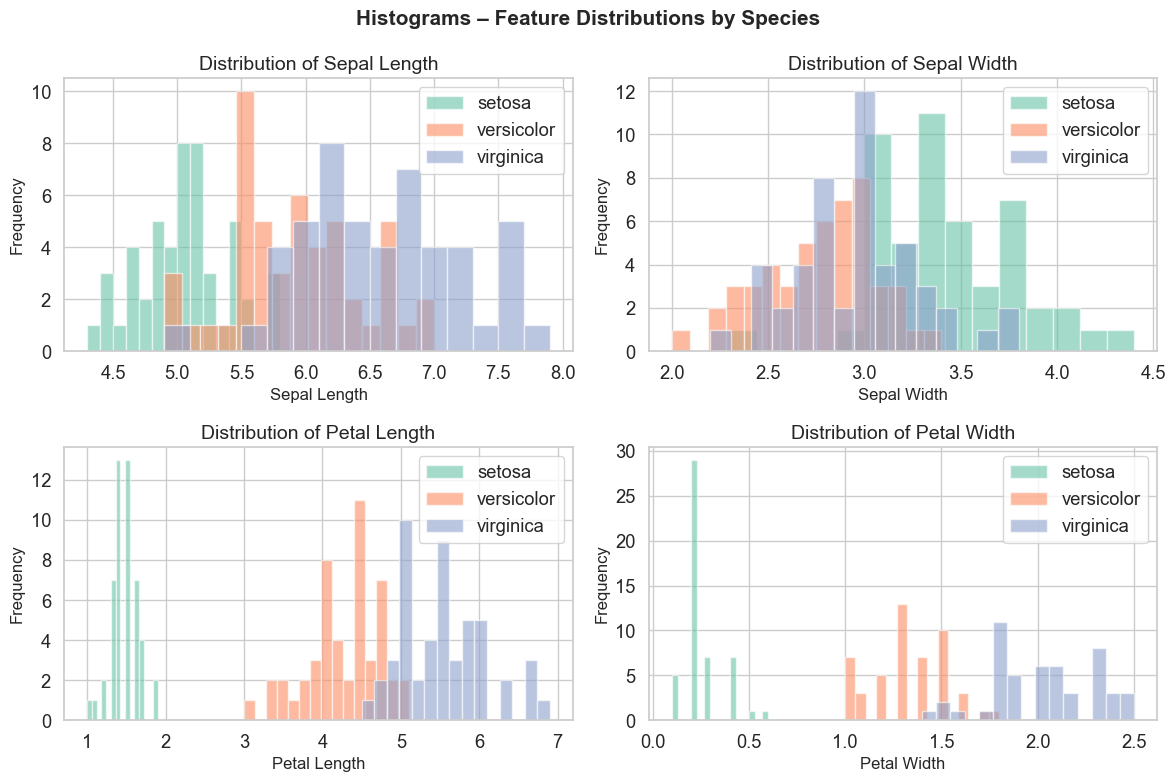


Insight: Petal length & width have bimodal distributions separating Setosa from others.


In [9]:
# Histogram for each numeric feature
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for species, grp in df.groupby('species'):
        axes[i].hist(grp[feature], bins=15, alpha=0.6, label=species, edgecolor='white')
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.suptitle('Histograms – Feature Distributions by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Petal length & width have bimodal distributions separating Setosa from others.")


### 3.3 Box Plot – Spread and Outliers

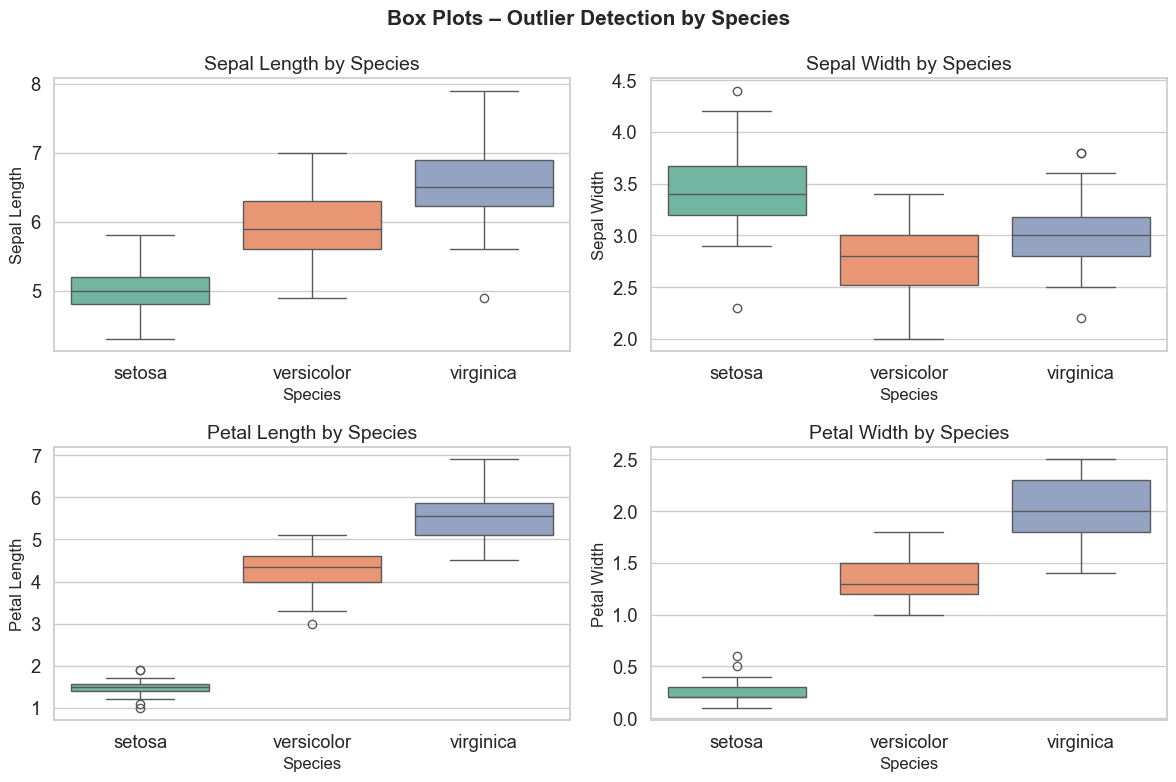


Insight: Sepal width has a few outliers in Setosa; petal features show tight clustering in Setosa.


In [10]:
# Box plots for all features grouped by species
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='species', y=feature, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{feature.replace("_", " ").title()} by Species')
    axes[i].set_xlabel('Species')
    axes[i].set_ylabel(feature.replace('_', ' ').title())

plt.suptitle('Box Plots – Outlier Detection by Species', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Sepal width has a few outliers in Setosa; petal features show tight clustering in Setosa.")


### 3.4 Pair Plot – Overall Relationship Overview

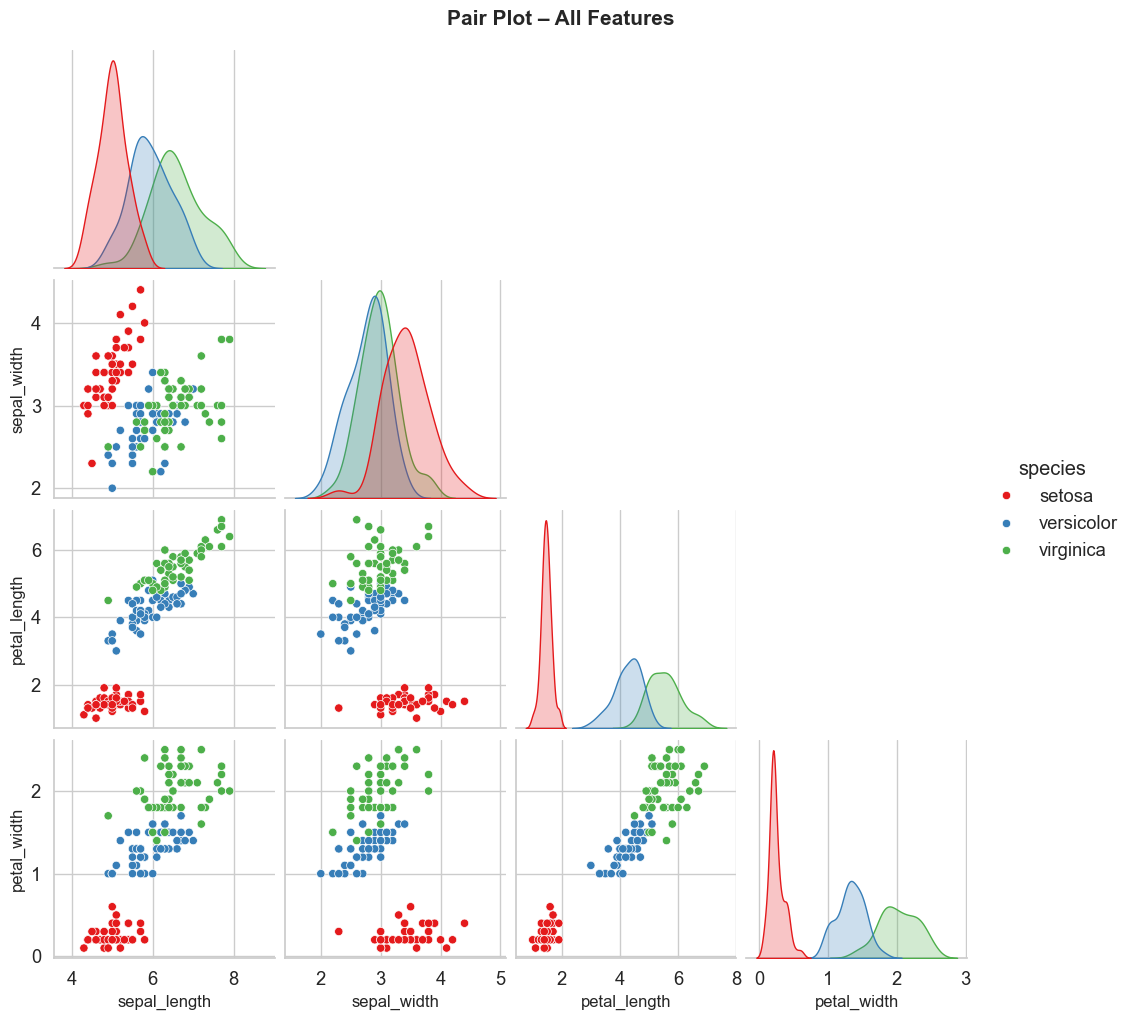

In [11]:
# Pair plot (bonus visualization)
pair = sns.pairplot(df, hue='species', palette='Set1', corner=True, diag_kind='kde')
pair.fig.suptitle('Pair Plot – All Features', y=1.02, fontsize=15, fontweight='bold')
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.5 Correlation Heatmap

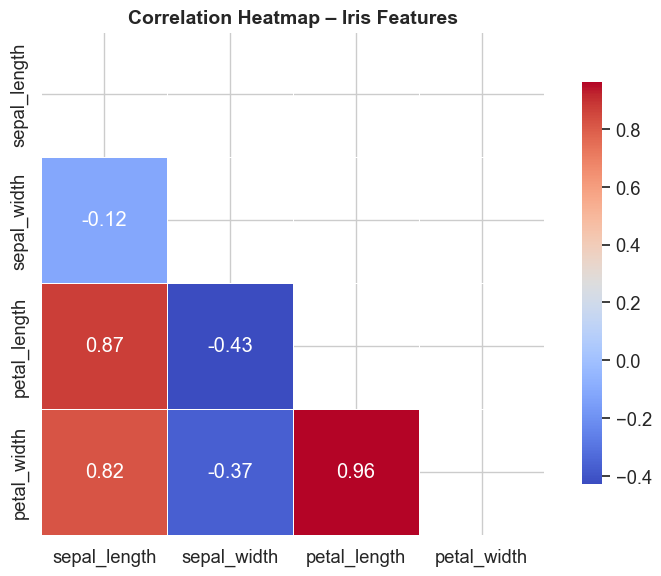


Insight: Petal length & petal width are highly correlated (r = 0.96).


In [12]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap – Iris Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInsight: Petal length & petal width are highly correlated (r = 0.96).")


## 4. Conclusion & Key Insights

| Finding | Detail |
|---|---|
| **Dataset** | 150 samples, 4 numeric features, 3 balanced species classes |
| **No missing data** | Dataset is clean and complete |
| **Best separating features** | Petal length and petal width clearly separate species |
| **Setosa** | Most distinct — smallest petals, easily separable |
| **Versicolor & Virginica** | Some overlap in sepal dimensions but separated by petals |
| **High correlation** | Petal length & petal width (r = 0.96), good for linear models |

These visualizations demonstrate that the Iris dataset is well-suited for classification — petal features alone would likely yield high accuracy with a simple model.
